In [3]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv(r"/home/satyajit-sahoo/Downloads/car data.csv")
dataset.head(4)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0


In [5]:
dataset.shape

(301, 9)

In [8]:
dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
dataset.Car_Name.value_counts()

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64

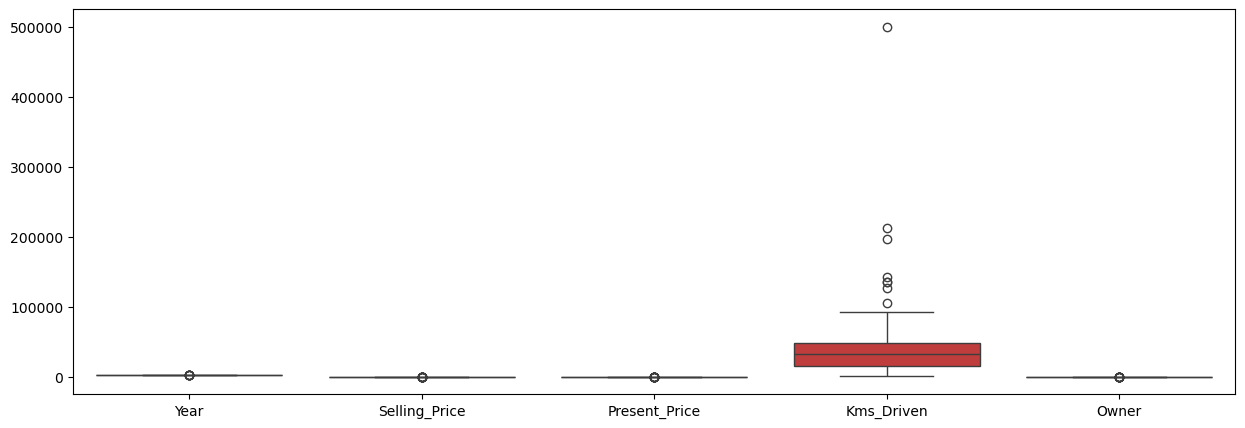

In [11]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=dataset)
plt.show()

In [12]:
# from the boxplot we can see that kms_Driven has outliers

In [14]:
q1 = dataset['Kms_Driven'].quantile(0.25)
q3 = dataset['Kms_Driven'].quantile(0.75)
iqr = q3-q1

max = q3 + (1.5 * iqr)
min = q1 - (1.5 * iqr)
print(iqr, max, min)

33767.0 99417.5 -35650.5


In [17]:
dataset[dataset['Kms_Driven']>max]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
37,800,2003,0.35,2.28,127000,Petrol,Individual,Manual,0
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0
53,fortuner,2013,16.00,30.61,135000,Diesel,Individual,Automatic,0
77,corolla,2004,1.50,12.35,135154,Petrol,Dealer,Automatic,0
84,innova,2005,3.49,13.46,197176,Diesel,Dealer,Manual,0
85,camry,2006,2.50,23.73,142000,Petrol,Individual,Automatic,3
179,Honda Karizma,2010,0.31,1.05,213000,Petrol,Individual,Manual,0
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0


In [18]:
dataset[dataset['Kms_Driven']>max].count()['Kms_Driven']

8

In [19]:
# These 8 values are greater than the upper limit value 99417.5

# We would remove these values

In [23]:
# Removal of outliers from Kms_Driven
dataset1 = dataset[dataset['Kms_Driven']<max]
dataset1

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


/tmp/ipykernel_228619/3333998257.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset1["Year"])


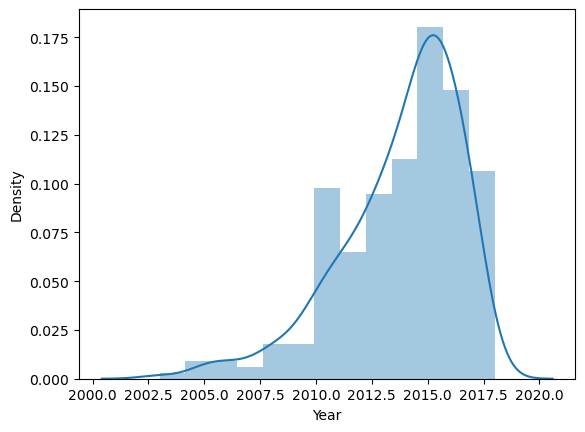

In [32]:
sns.distplot(dataset1["Year"])
plt.show()

/tmp/ipykernel_228619/2255723650.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset1["Present_Price"])


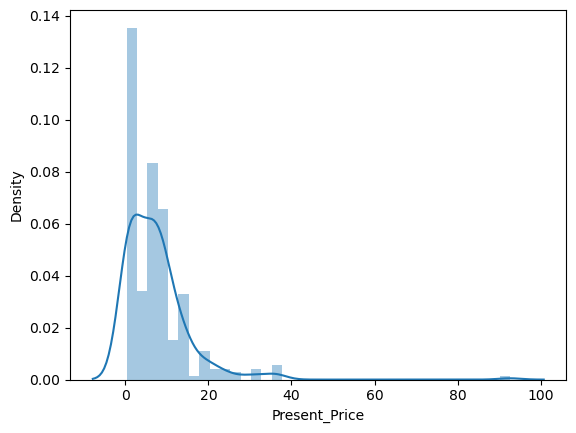

In [33]:
sns.distplot(dataset1["Present_Price"])
plt.show()

/tmp/ipykernel_228619/1913232147.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset1["Kms_Driven"])


<function matplotlib.pyplot.show(close=None, block=None)>

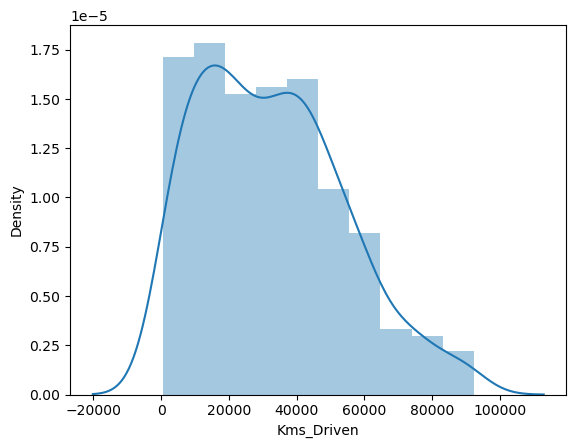

In [34]:
sns.distplot(dataset1["Kms_Driven"])
plt.show

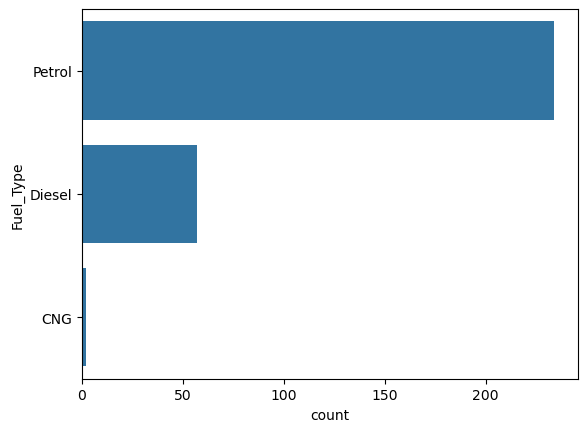

In [43]:
sns.countplot(dataset1['Fuel_Type'])
plt.show()

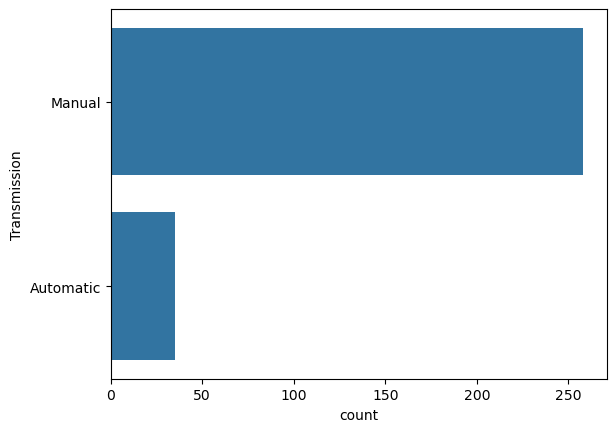

In [44]:
sns.countplot(dataset1['Transmission'])
plt.show()

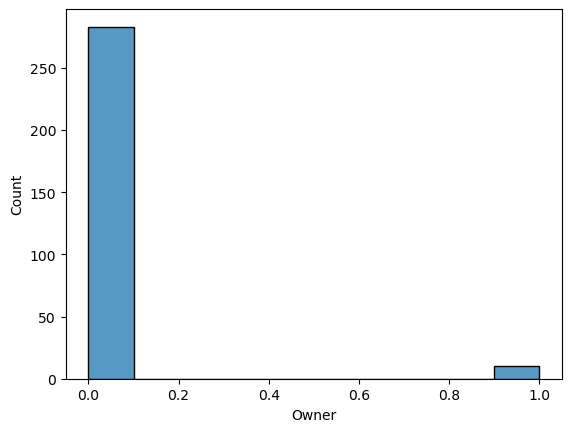

In [49]:
sns.histplot(dataset1['Owner'])
plt.show()

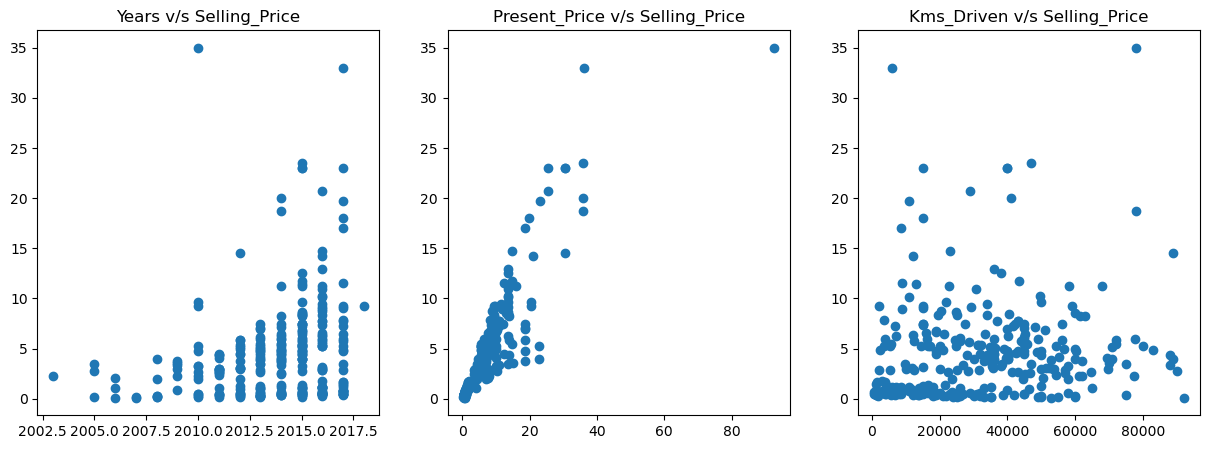

In [60]:
fig, (ax1, ax2,ax3) = plt.subplots(1,3,figsize = (15,5))

#scatter plot 1
ax1.scatter(x='Year',y= 'Selling_Price', data=dataset1)
ax1.set_title('Years v/s Selling_Price')

#scatter plot 2
ax2.scatter(x='Present_Price', y='Selling_Price', data=dataset1) 
ax2.set_title('Present_Price v/s Selling_Price')

#scatter plot 3
ax3.scatter(x='Kms_Driven',y='Selling_Price', data=dataset1)
ax3.set_title('Kms_Driven v/s Selling_Price')

plt.draw()

Text(0.5, 1.0, 'Seller_Type v/s Selling_Price')

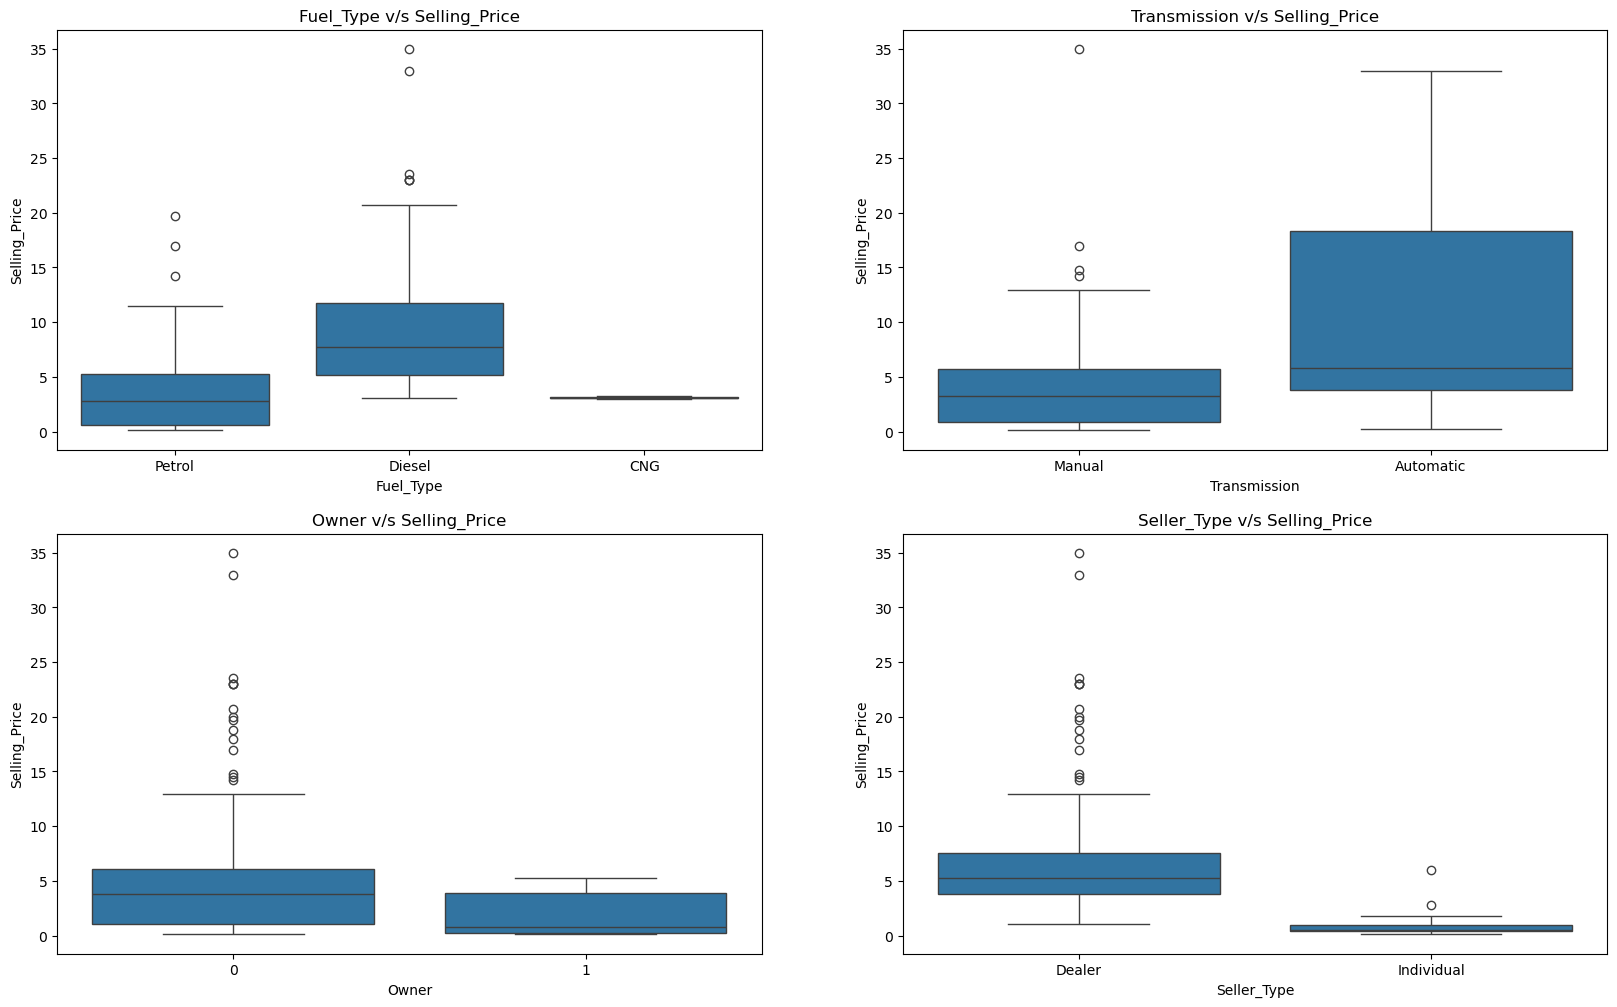

In [62]:
fig,axes = plt.subplots(2,2,figsize=(20,12))

sns.boxplot(x='Fuel_Type',y='Selling_Price',ax=axes[0][0], data=dataset1)
axes[0][0].set_title('Fuel_Type v/s Selling_Price')

sns.boxplot(x='Transmission',y='Selling_Price',ax=axes[0][1], data=dataset1)
axes[0][1].set_title('Transmission v/s Selling_Price')

sns.boxplot(x='Owner',y='Selling_Price',ax=axes[1][0], data=dataset1)
axes[1][0].set_title('Owner v/s Selling_Price')

sns.boxplot(x='Seller_Type',y='Selling_Price',ax=axes[1][1], data=dataset1)
axes[1][1].set_title('Seller_Type v/s Selling_Price')

In [63]:
# 1. The Diesel cars are having the highest selling_price with most number of outliers being present. Diesel > CNG > Petrol in terms of seeling price
# 2. Automatic cars are expesnive than manual cars
# 3. The cars with no previous owner are expensive than with a previous owner.
# 4. Individuals are selling there cars at lesser price than the cars being sold by the dealers

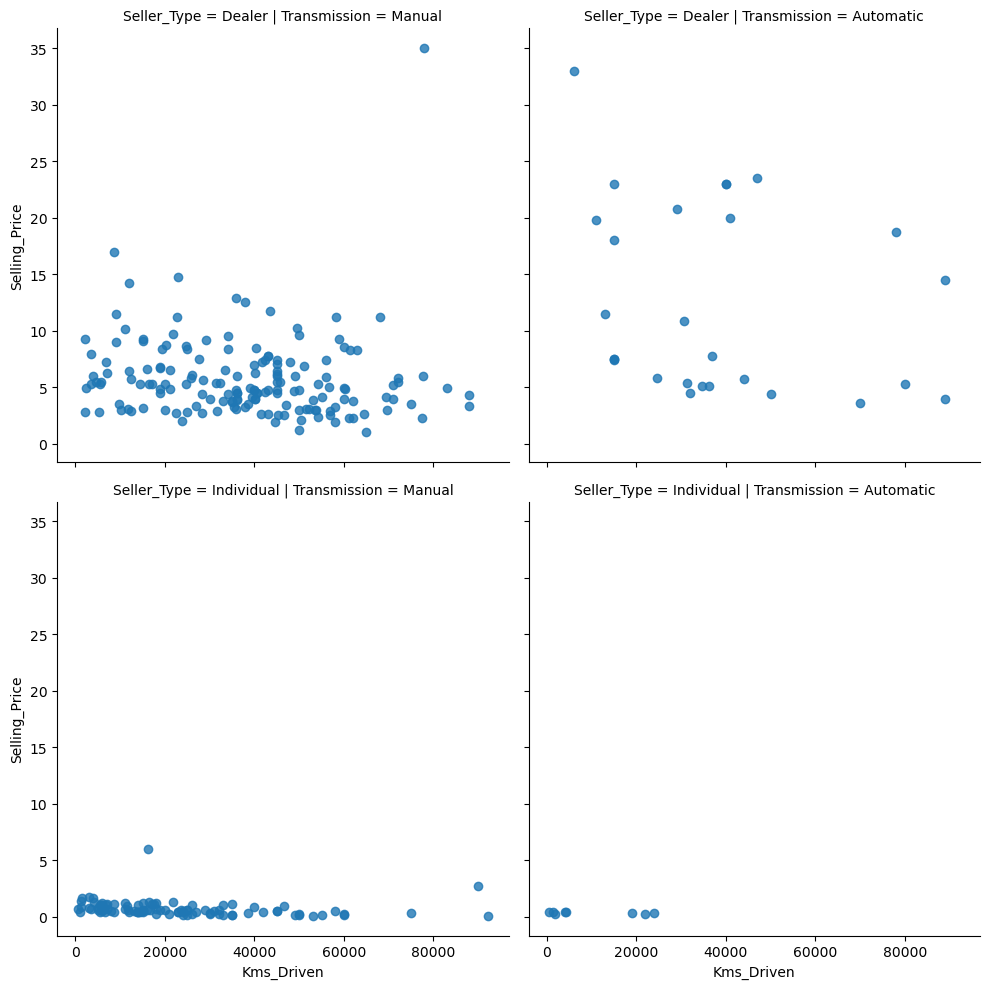

In [65]:
sns.lmplot(x='Kms_Driven',y='Selling_Price',data=dataset1,fit_reg=False,col='Transmission',row='Seller_Type')   
plt.show()

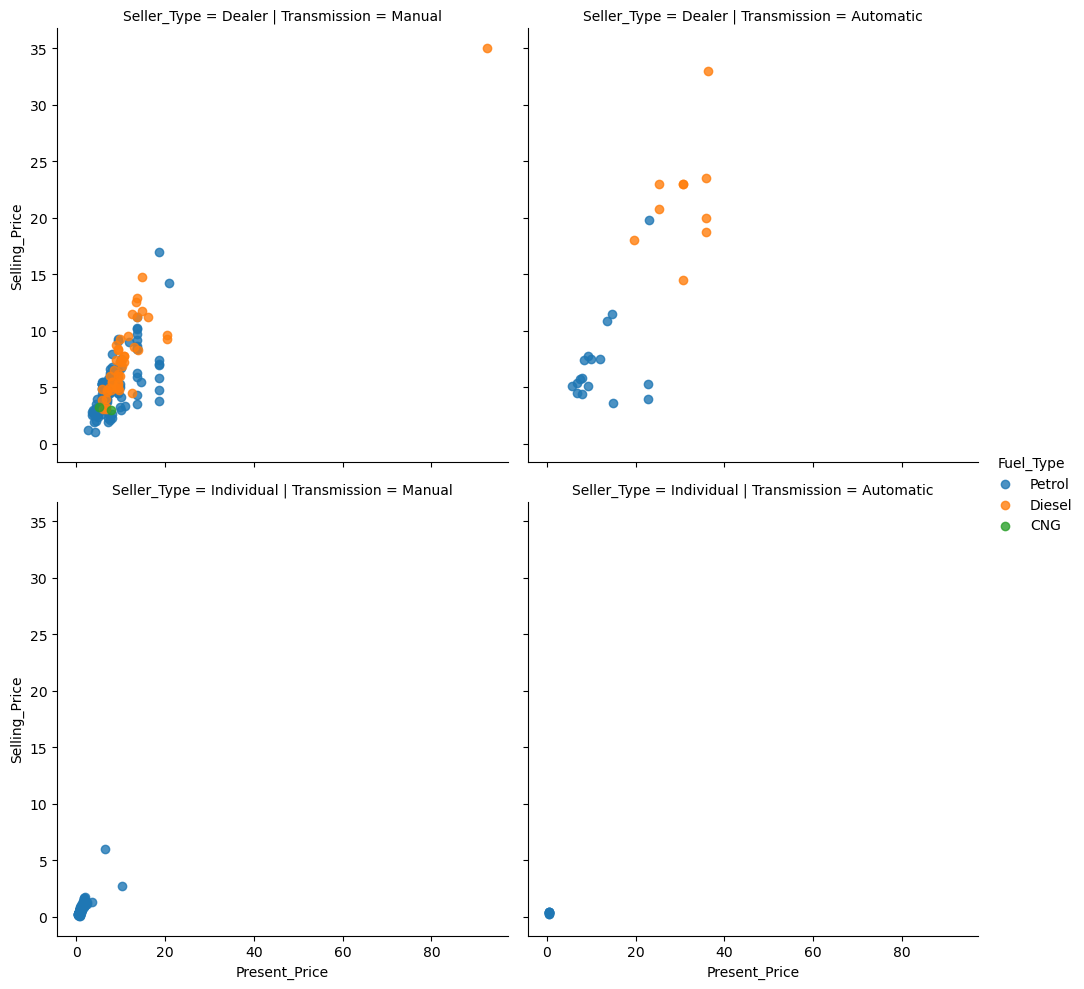

In [68]:
sns.lmplot(x='Present_Price',y='Selling_Price',data=dataset1,fit_reg=False,col='Transmission',row='Seller_Type',hue='Fuel_Type')   
plt.show()

In [69]:
dataset1.Fuel_Type.value_counts()

Fuel_Type
Petrol    234
Diesel     57
CNG         2
Name: count, dtype: int64

In [70]:
dataset1.Seller_Type.value_counts()

Seller_Type
Dealer        192
Individual    101
Name: count, dtype: int64

In [71]:
dataset1.Transmission.value_counts()

Transmission
Manual       258
Automatic     35
Name: count, dtype: int64

In [72]:
dataset2 = pd.get_dummies(dataset1,columns=['Fuel_Type','Seller_Type','Transmission'],drop_first=True)

In [73]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 300
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Car_Name                293 non-null    object 
 1   Year                    293 non-null    int64  
 2   Selling_Price           293 non-null    float64
 3   Present_Price           293 non-null    float64
 4   Kms_Driven              293 non-null    int64  
 5   Owner                   293 non-null    int64  
 6   Fuel_Type_Diesel        293 non-null    bool   
 7   Fuel_Type_Petrol        293 non-null    bool   
 8   Seller_Type_Individual  293 non-null    bool   
 9   Transmission_Manual     293 non-null    bool   
dtypes: bool(4), float64(2), int64(3), object(1)
memory usage: 17.2+ KB


In [74]:
dataset2.shape

(293, 10)

In [77]:
dataset2.drop(['Car_Name'],axis=1,inplace = True)

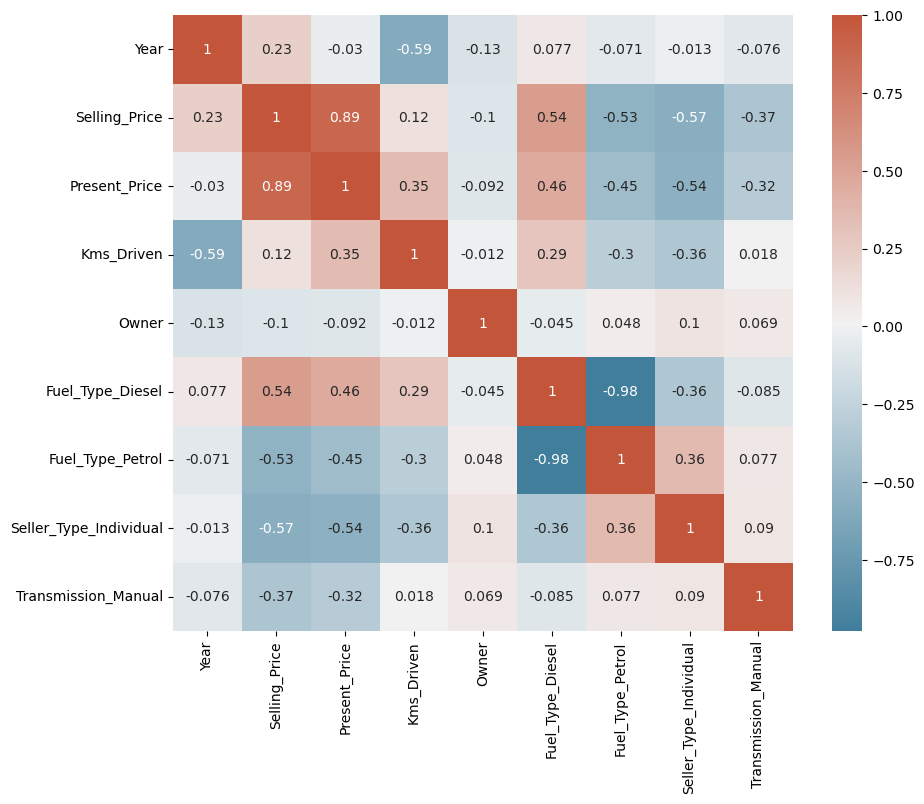

In [79]:
plt.figure(figsize = (10, 8))

cmap = sns.diverging_palette(230, 20, as_cmap = True)

sns.heatmap(dataset2.corr(), annot = True, cmap = cmap)

plt.show()